# Phase 1 Capstone

## Stage 1 — Frame the Question

### 1. Primary Question

Which applicant characteristics are most strongly associated with loan approval?

##### Why This Question Matters

Loan approval is the main outcome in this dataset. By analyzing applicant characteristics such as **Credit History, Applicant Income, Education, Property Area, Marital Status, Dependents, and Self-Employment status**, we can identify patterns associated with approval and rejection.

The goal is **not to assume that any particular characteristic causes approval**. Instead, the analysis will determine which characteristics show the strongest relationships with the observed loan approval outcomes.


### 2. Supporting Questions

#### 01. Credit History

**How strongly is Credit History associated with loan approval?**

This will help determine whether applicants with different credit-history records have noticeably different approval rates.

#### 02. Applicant Income

**Does Applicant Income differ meaningfully between approved and rejected loan applications?**

This will help determine whether income shows a noticeable relationship with the observed approval outcome.

#### 03. Applicant Characteristics

**Do Education, Property Area, Marital Status, or Self-Employment status show meaningful differences in loan approval rates?**

This will help identify whether categorical applicant characteristics are associated with different approval outcomes.


### 3. Who Cares About the Answer?

* **Bank / Loan Officer:** To understand which applicant characteristics are associated with loan approval.
* **Loan Applicant:** To understand which recorded characteristics are associated with approval outcomes.
* **Data Analyst:** To identify and communicate meaningful relationships in the loan application data.


## Stage 2 — Assess the data before you touch it

In [ ]:
#import require libraries
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
#read a csv file
df=pd.read_csv('loan_approved.csv')

In [4]:
#show a first 5 rows
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [5]:
#show last five rows
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [6]:
#count a rows and column
df.shape

(614, 13)

In [7]:
#show all the  column name 
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area',
       'Loan_Status (Approved)'],
      dtype='str')

In [8]:
#give me column name and what types of data it's have 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Loan_ID                 614 non-null    str    
 1   Gender                  601 non-null    str    
 2   Married                 611 non-null    str    
 3   Dependents              599 non-null    str    
 4   Education               614 non-null    str    
 5   Self_Employed           582 non-null    str    
 6   ApplicantIncome         614 non-null    int64  
 7   CoapplicantIncome       614 non-null    float64
 8   LoanAmount              592 non-null    float64
 9   Loan_Amount_Term        600 non-null    float64
 10  Credit_History          564 non-null    float64
 11  Property_Area           614 non-null    str    
 12  Loan_Status (Approved)  614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 83.4 KB


In [9]:
#count a null values
df.isnull().sum()

Loan_ID                    0
Gender                    13
Married                    3
Dependents                15
Education                  0
Self_Employed             32
ApplicantIncome            0
CoapplicantIncome          0
LoanAmount                22
Loan_Amount_Term          14
Credit_History            50
Property_Area              0
Loan_Status (Approved)     0
dtype: int64

In [10]:
#all the null values convert into a %
df.isnull().mean() * 100

Loan_ID                   0.000000
Gender                    2.117264
Married                   0.488599
Dependents                2.442997
Education                 0.000000
Self_Employed             5.211726
ApplicantIncome           0.000000
CoapplicantIncome         0.000000
LoanAmount                3.583062
Loan_Amount_Term          2.280130
Credit_History            8.143322
Property_Area             0.000000
Loan_Status (Approved)    0.000000
dtype: float64

In [11]:
#give a statistical information about a numerical column
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [12]:
#give a statistical information about a categorical column
df.describe(include='O')

C:\Users\dell\AppData\Local\Temp\ipykernel_22048\492389678.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='O')


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status (Approved)
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP001002,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


In [13]:
df['Loan_Status (Approved)'].value_counts()

Loan_Status (Approved)
Y    422
N    192
Name: count, dtype: int64

In [14]:
for col in [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Credit_History",
    "Property_Area",
    "Loan_Status (Approved)"
]:
    print("\n", col)
    print(df[col].unique())


 Gender
<ArrowStringArray>
['Male', 'Female', nan]
Length: 3, dtype: str

 Married
<ArrowStringArray>
['No', 'Yes', nan]
Length: 3, dtype: str

 Dependents
<ArrowStringArray>
['0', '1', '2', '3+', nan]
Length: 5, dtype: str

 Education
<ArrowStringArray>
['Graduate', 'Not Graduate']
Length: 2, dtype: str

 Self_Employed
<ArrowStringArray>
['No', 'Yes', nan]
Length: 3, dtype: str

 Credit_History
[ 1.  0. nan]

 Property_Area
<ArrowStringArray>
['Urban', 'Rural', 'Semiurban']
Length: 3, dtype: str

 Loan_Status (Approved)
<ArrowStringArray>
['Y', 'N']
Length: 2, dtype: str


## Stage 3 — Clean 

In [15]:
df_clean = df.copy()

In [16]:
df_clean.duplicated().sum()

np.int64(0)

In [17]:
# there is no any duplicate record in the dataset

In [18]:
#check a missing values
df_clean.isnull().sum()

Loan_ID                    0
Gender                    13
Married                    3
Dependents                15
Education                  0
Self_Employed             32
ApplicantIncome            0
CoapplicantIncome          0
LoanAmount                22
Loan_Amount_Term          14
Credit_History            50
Property_Area              0
Loan_Status (Approved)     0
dtype: int64

In [19]:
#show all statistical information of numerical column
df_clean.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [20]:
#loanamount have a missing values and it fill with the median 
df_clean.loc[df_clean.LoanAmount.isnull(),'LoanAmount'] = df_clean.LoanAmount.median()

In [21]:
#Loan_Amount_Term have a missing values and it fill with the median 
df_clean.loc[df_clean.Loan_Amount_Term.isnull(),'Loan_Amount_Term'] = df_clean.Loan_Amount_Term.median()

In [22]:
# To display only categorical columns
df_clean.select_dtypes(include='O').columns

C:\Users\dell\AppData\Local\Temp\ipykernel_22048\1281544312.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_clean.select_dtypes(include='O').columns


Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'Property_Area', 'Loan_Status (Approved)'],
      dtype='str')

In [23]:
# To display only numerical columns
df_clean.select_dtypes(include='number').columns

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='str')

In [24]:
# handle missing values for married columns :
df_clean.loc[df_clean.Married.isnull(),'Married'] = df_clean.Married.mode()[0]

In [25]:
# handle missing values of dependents column:
df_clean.loc[df_clean.Dependents.isnull(),'Dependents'] = df_clean.Dependents.mode()[0]

In [26]:
# handle missing values for Self_Employed columns :
df_clean.loc[df_clean.Self_Employed.isnull(),'Self_Employed'] = df_clean.Self_Employed.mode()[0]

In [27]:
# Impute missing values for Credit_History columns : It shoud be replace by '0'
df_clean.loc[df_clean.Credit_History.isnull(),'Credit_History'] = 0.0

In [28]:
# Impute Null values in Gender Columns : 
df_clean.loc[df_clean.Gender.isnull(),'Gender'] = df_clean.Gender.mode()[0]

In [29]:
#check a missing values
df_clean.isnull().sum()

Loan_ID                   0
Gender                    0
Married                   0
Dependents                0
Education                 0
Self_Employed             0
ApplicantIncome           0
CoapplicantIncome         0
LoanAmount                0
Loan_Amount_Term          0
Credit_History            0
Property_Area             0
Loan_Status (Approved)    0
dtype: int64

In [30]:
# now there is no any missing values in the dataset

<Axes: >

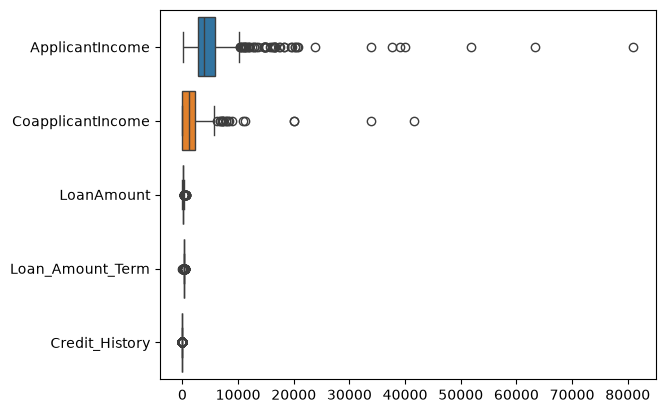

In [31]:
#Handling Outliers:
# Finding the Outliers
sns.boxplot(df_clean, orient='h')

<Axes: xlabel='CoapplicantIncome'>

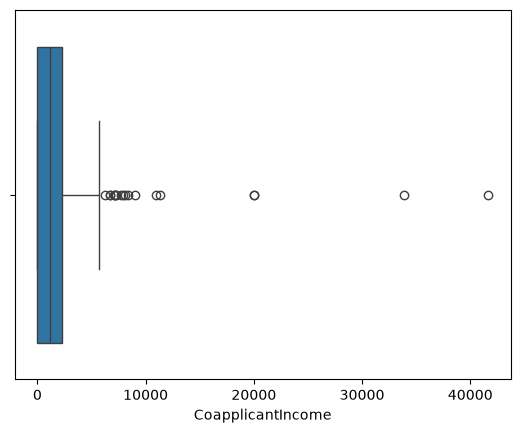

In [32]:
# Finding the Outliers for coapplicant_income 
sns.boxplot(df_clean.CoapplicantIncome, orient='h')

In [33]:
# Get the Upper bound and lower bound for CoapplicantIncome
Q1 = df_clean.CoapplicantIncome.quantile(0.25)
Q3 = df_clean.CoapplicantIncome.quantile(0.75)
IQR = Q3-Q1
LB = Q1-IQR*1.5
UB = Q3+IQR*1.5
UB,LB

(np.float64(5743.125), np.float64(-3445.875))

In [34]:
# Replace the Outliers of CoapplicantIncome by 'median'
df_clean.loc[df_clean.CoapplicantIncome>5700,'CoapplicantIncome'] = df_clean.CoapplicantIncome.median()

In [35]:
# Finding Outliers for Loan_Ammount :
Q1 = df_clean.LoanAmount.quantile(0.25)
Q3 = df_clean.LoanAmount.quantile(0.75)
IQR = Q3 - Q1
UB = Q3+IQR*1.5
LB = Q1-IQR*1.5
print('Upper Bound = ',UB, 'Lower Bound = ',LB)

Upper Bound =  261.5 Lower Bound =  3.5


In [36]:
# Replace the outliers in LoanAmount columnLoanAmount<3.5
df_clean.loc[(df_clean.LoanAmount<LB) |(df_clean.LoanAmount>UB),'LoanAmount'] = df_clean.LoanAmount.median()

In [37]:
# Handling Outliers of ApplicantIncome using median as an Integer.
df_clean.loc[df_clean.ApplicantIncome>7500,'ApplicantIncome'] = 3812

<Axes: >

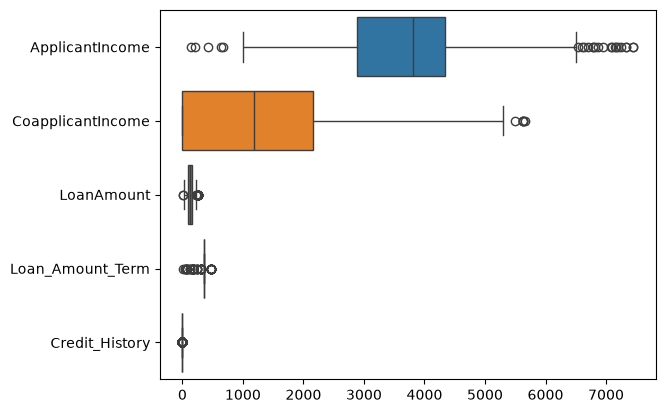

In [38]:
#Handling Outliers:
# Finding the Outliers
sns.boxplot(df_clean, orient='h')


1. The raw dataset was preserved and a separate copy was created for cleaning.

2. Exact duplicate rows were checked. Duplicate records were removed only if they were identified as exact duplicates.

3. Missing numeric values were investigated before imputation. Median imputation was used where appropriate because the median is less sensitive to extreme values.

4. Missing categorical values were handled using the most frequent category where appropriate.

5. Negative or logically impossible numeric values were checked rather than automatically removed.

6. Potential outliers in ApplicantIncome, CoapplicantIncome, and LoanAmount were investigated using summary statistics and boxplots. Extreme observations were not automatically deleted because they may represent genuine applicants.

7. Numeric columns were converted to numeric data types where necessary.

8. Potentially misaligned records were investigated separately because they may represent structural data-quality issues rather than ordinary missing values.

9. The cleaned dataset was compared with the original dataset to evaluate changes in row count, missing values, mean, standard deviation, and median.

## Stage 4 — Exploratory Data Analysis(EDA)

1. Understand the cleaned data and find patterns that can help answer your primary question.
2. Which applicant characteristics are most strongly associated with loan approval, and can the available application data help identify patterns that distinguish approved applications from rejected applications?

In [39]:
df_clean.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [40]:
df_clean.shape

(614, 13)

In [41]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Loan_ID                 614 non-null    str    
 1   Gender                  614 non-null    str    
 2   Married                 614 non-null    str    
 3   Dependents              614 non-null    str    
 4   Education               614 non-null    str    
 5   Self_Employed           614 non-null    str    
 6   ApplicantIncome         614 non-null    int64  
 7   CoapplicantIncome       614 non-null    float64
 8   LoanAmount              614 non-null    float64
 9   Loan_Amount_Term        614 non-null    float64
 10  Credit_History          614 non-null    float64
 11  Property_Area           614 non-null    str    
 12  Loan_Status (Approved)  614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 83.2 KB


In [42]:
df_clean["Loan_Status (Approved)"].value_counts()

Loan_Status (Approved)
Y    422
N    192
Name: count, dtype: int64

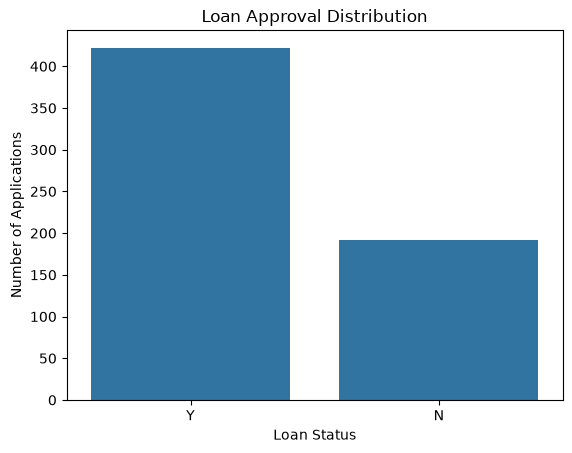

In [43]:
sns.countplot(
    data=df_clean,
    x="Loan_Status (Approved)"
)

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")
plt.show()

#### conclusion

- The distribution of Loan_Status shows how many applications were approved
and rejected in the dataset. This gives an initial understanding of the
outcome variable and shows whether the two outcome groups are balanced.

### Credit_History VS Loan_Status (Approved)

In [44]:
pd.crosstab(
    df_clean["Credit_History"],
    df_clean["Loan_Status (Approved)"]
)

Loan_Status (Approved),N,Y
Credit_History,,
0.0,95,44
1.0,97,378


In [45]:
credit_approval = pd.crosstab(
    df_clean["Credit_History"],
    df_clean["Loan_Status (Approved)"],
    normalize="index"
) * 100

credit_approval

Loan_Status (Approved),N,Y
Credit_History,,
0.0,68.345324,31.654676
1.0,20.421053,79.578947


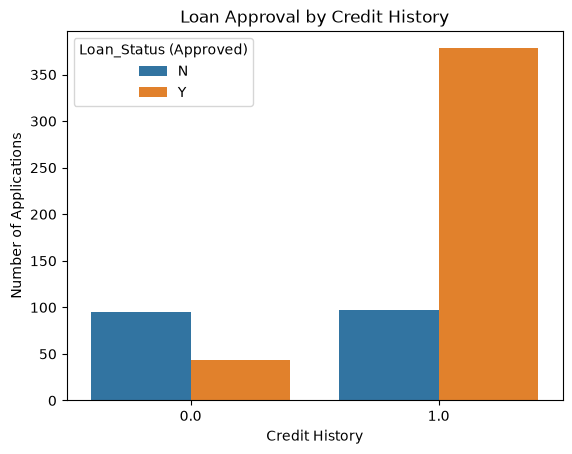

In [46]:
sns.countplot(
    data=df_clean,
    x="Credit_History",
    hue="Loan_Status (Approved)"
)

plt.title("Loan Approval by Credit History")
plt.xlabel("Credit History")
plt.ylabel("Number of Applications")
plt.show()

#### conclusion

Loan approval patterns differ across Credit_History categories. This makes
Credit_History an important variable to investigate further because the
approval distribution is not necessarily the same for every credit-history
group.

### Applicant Income vs Loan Status

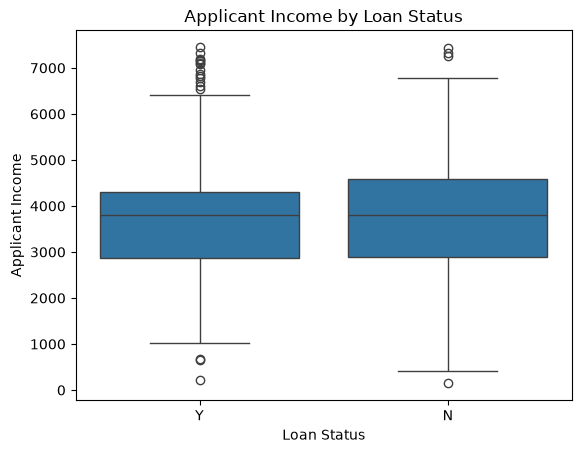

In [47]:
#Does Applicant Income differ meaningfully between approved and rejected applications?
sns.boxplot(
    data=df_clean,
    x="Loan_Status (Approved)",
    y="ApplicantIncome"
)

plt.title("Applicant Income by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Applicant Income")
plt.show()

### conclusion

- Applicant income distributions are compared between approved and rejected
applications using their median, spread, and overall distribution.

- The boxplot also helps identify extreme income values that may affect
comparisons between the two groups.

### Education Income vs Loan Status

In [48]:
#Does loan approval differ between education categories?
education_approval = pd.crosstab(
    df_clean["Education"],
    df_clean["Loan_Status (Approved)"],
    normalize="index"
) * 100

education_approval

Loan_Status (Approved),N,Y
Education,,
Graduate,29.166667,70.833333
Not Graduate,38.805970,61.194030


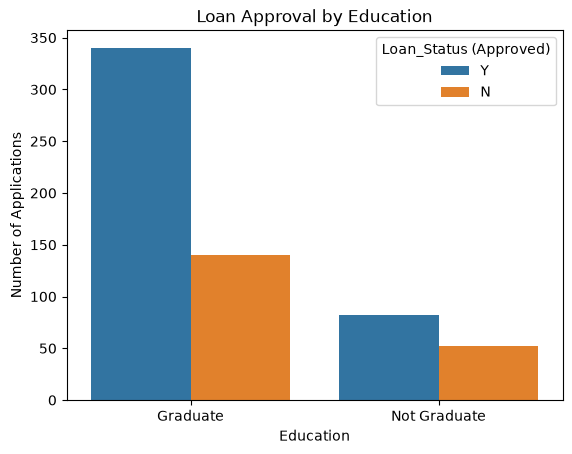

In [49]:
sns.countplot(
    data=df_clean,
    x="Education",
    hue="Loan_Status (Approved)"
)

plt.title("Loan Approval by Education")
plt.xlabel("Education")
plt.ylabel("Number of Applications")
plt.show()

#### conclusion

- The approval distribution is compared between the education categories to
determine whether the historical approval pattern differs across these
groups.

### Property Area vs Loan Approval

In [50]:
property_approval = pd.crosstab(
    df_clean["Property_Area"],
    df_clean["Loan_Status (Approved)"],
    normalize="index"
) * 100

property_approval

Loan_Status (Approved),N,Y
Property_Area,,
Rural,38.547486,61.452514
Semiurban,23.175966,76.824034
Urban,34.158416,65.841584


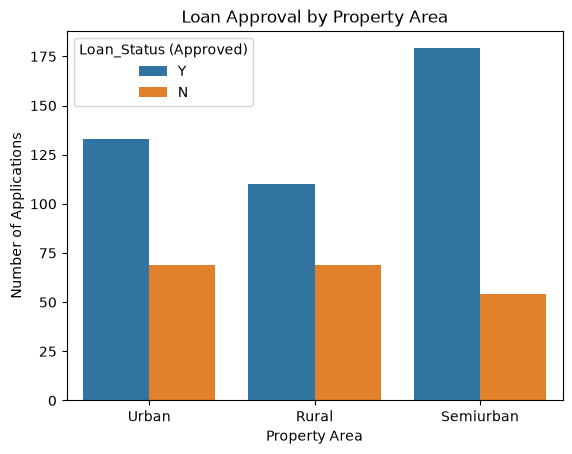

In [51]:
sns.countplot(
    data=df_clean,
    x="Property_Area",
    hue="Loan_Status (Approved)"
)

plt.title("Loan Approval by Property Area")
plt.xlabel("Property Area")
plt.ylabel("Number of Applications")
plt.show()

#### conclusion

- Loan approval patterns are compared across property-area categories.
Differences between these groups indicate that Property_Area may be useful
for understanding historical approval patterns.

### Married Status vs Loan Approval

In [52]:
#Does approval differ between married and unmarried applicants?
married_approval = pd.crosstab(
    df_clean["Married"],
    df_clean["Loan_Status (Approved)"],
    normalize="index"
) * 100

married_approval

Loan_Status (Approved),N,Y
Married,,
No,37.089202,62.910798
Yes,28.179551,71.820449


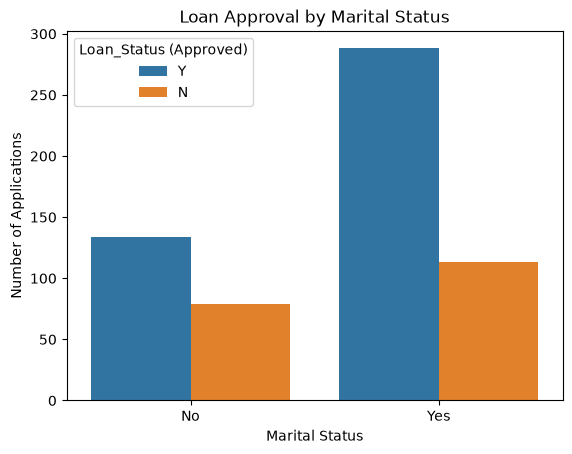

In [53]:
sns.countplot(
    data=df_clean,
    x="Married",
    hue="Loan_Status (Approved)"
)

plt.title("Loan Approval by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Number of Applications")
plt.show()

#### conclusion

- The approval distribution is compared between married and unmarried
applicants to determine whether marital status is associated with different
historical approval patterns.

### Self-Employment vs Loan Approval


In [54]:
self_employed_approval = pd.crosstab(
    df_clean["Self_Employed"],
    df_clean["Loan_Status (Approved)"],
    normalize="index"
) * 100

self_employed_approval

Loan_Status (Approved),N,Y
Self_Employed,,
No,31.203008,68.796992
Yes,31.707317,68.292683


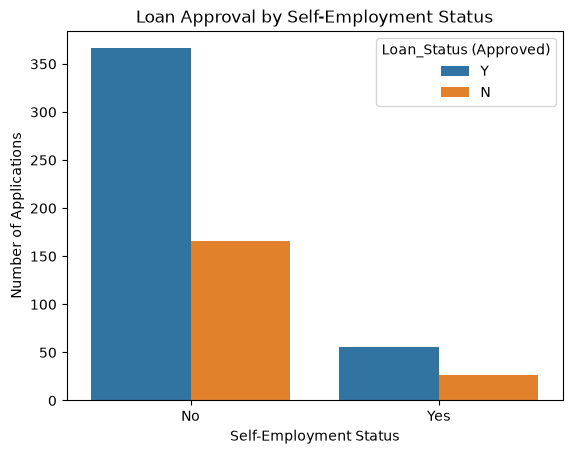

In [55]:
sns.countplot(
    data=df_clean,
    x="Self_Employed",
    hue="Loan_Status (Approved)"
)

plt.title("Loan Approval by Self-Employment Status")
plt.xlabel("Self-Employment Status")
plt.ylabel("Number of Applications")
plt.show()

#### conclusion

- The approval distribution is compared between self-employed and
non-self-employed applicants to determine whether their historical approval
patterns differ.

### Loan Amount vs Loan Status

In [56]:
#Does the requested loan amount differ between approved and rejected applications?
df_clean.groupby(
    "Loan_Status (Approved)"
)["LoanAmount"].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
Loan_Status (Approved),,,,
N,192,130.145833,128.0,45.339898
Y,422,127.680095,128.0,44.584485


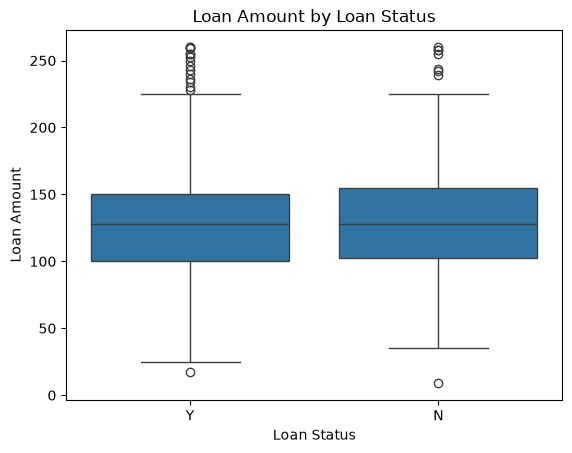

In [57]:
sns.boxplot(
    data=df_clean,
    x="Loan_Status (Approved)",
    y="LoanAmount"
)

plt.title("Loan Amount by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Loan Amount")
plt.show()

#### conclusion

- The distribution of requested LoanAmount is compared between approved and
rejected applications. The comparison considers differences in the median,
spread, and extreme observations.

### Third-variable breakdown

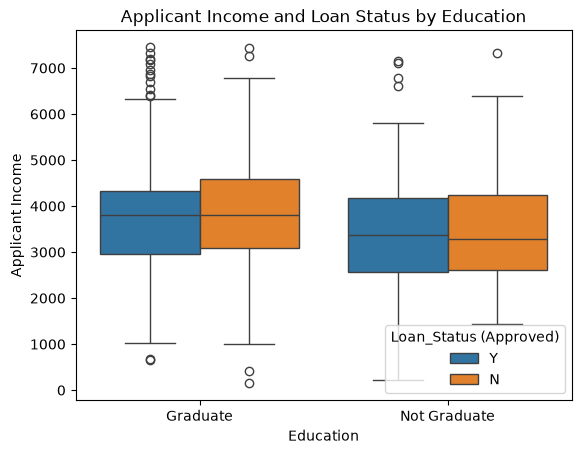

In [58]:
sns.boxplot(
    data=df_clean,
    x="Education",
    y="ApplicantIncome",
    hue="Loan_Status (Approved)"
)

plt.title("Applicant Income and Loan Status by Education")
plt.xlabel("Education")
plt.ylabel("Applicant Income")
plt.show()

#### Third-Variable Analysis

- Applicant Income was first compared with Loan_Status at the overall
dataset level. The relationship was then examined separately within
Education groups.

- This subgroup analysis was performed to determine whether the overall
income-approval pattern remains consistent across education categories.

- The subgroup results should be compared with the overall result before
drawing a conclusion.

### Correlation Matrix

In [59]:
numeric_cols = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History"
]

correlation = df_clean[numeric_cols].corr()

correlation

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
ApplicantIncome,1.000000,-0.174943,0.308698,-0.024196,0.005692
CoapplicantIncome,-0.174943,1.000000,0.219589,0.016986,-0.040071
LoanAmount,0.308698,0.219589,1.000000,0.079114,-0.020630
Loan_Amount_Term,-0.024196,0.016986,0.079114,1.000000,0.002361
Credit_History,0.005692,-0.040071,-0.020630,0.002361,1.000000


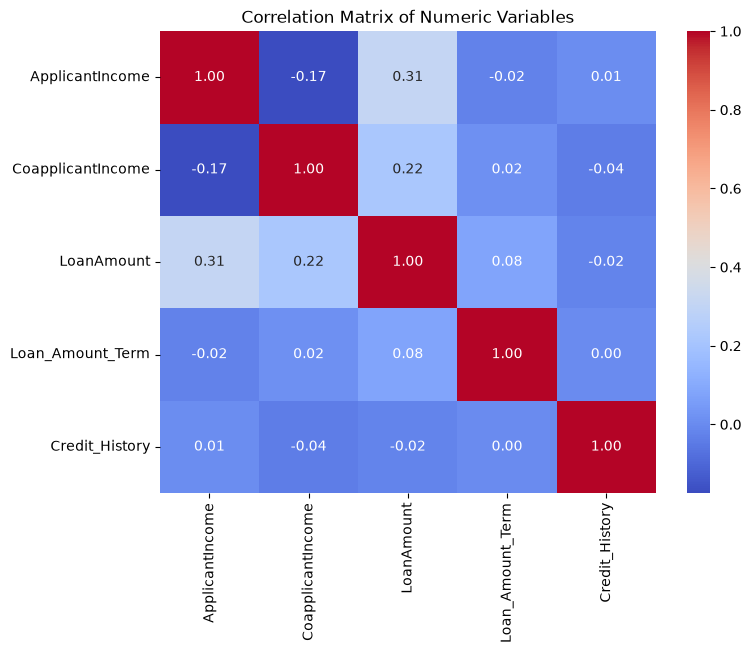

In [60]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numeric Variables")
plt.show()

#### Correlation 

- ApplicantIncome and LoanAmount have the strongest positive correlation (0.303), followed by CoapplicantIncome and LoanAmount (0.249). ApplicantIncome and CoapplicantIncome show a weak negative correlation (-0.175). Overall, most numeric variables have weak or near-zero linear relationships.

In [61]:
df_clean.groupby(
    ["Education", "Loan_Status (Approved)"]
)["ApplicantIncome"].agg(
    ["count", "mean", "median"]
)

count         mean  median
Education    Loan_Status (Approved)                            
Graduate     N                         140  3837.478571  3812.0
             Y                         340  3806.917647  3812.0
Not Graduate N                          52  3572.442308  3279.0
             Y                          82  3474.170732  3378.0

In [62]:
pd.crosstab(
    df_clean["Property_Area"],
    df_clean["Loan_Status (Approved)"],
    normalize="index"
) * 100

Loan_Status (Approved),N,Y
Property_Area,,
Rural,38.547486,61.452514
Semiurban,23.175966,76.824034
Urban,34.158416,65.841584


#### Surprising Finding

- At first, ApplicantIncome appeared to be an important variable to compare with loan approval. However, after splitting the data by Education, the income difference became small within each group. Among graduates, both approved and rejected applicants have the same median income (3812). Among non-graduates, the median income is only slightly higher for approved applicants (3378 vs. 3279). This suggests that the overall income pattern does not remain strong within the Education groups.

#### Investigation

- The subgroup analysis shows that Education changes how the ApplicantIncome and Loan_Status relationship appears. Therefore, ApplicantIncome alone does not show a large difference between approved and rejected applications within the Education groups.

## Stage 5 — Test two hypotheses

#### Hypothesis 1 — Credit History and Loan Approval

Is Credit History associated with Loan Approval?

- H₀ — Null hypothesis

    - There is no association between Credit History and Loan Approval.

- H₁ — Alternative hypothesis

    - There is an association between Credit History and Loan Approval.

In [63]:
# H₀: Credit History and loan approval are independent.
# H₁: Credit History and loan approval are not independent.

# Contingency table
table = pd.crosstab(
    df_clean["Credit_History"],
    df_clean["Loan_Status (Approved)"]
)

print("Contingency Table:")
print(table)

# Chi-square test
chi2, p, dof, expected = stats.chi2_contingency(table)

print("\nChi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

alpha = 0.05

if p < alpha:
    print("Reject H₀: There is an association between Credit History and loan approval.")
else:
    print("Fail to reject H₀: There is not enough evidence of an association.")

# The results show whether Credit History is associated with loan approval.
# This means that the pattern of loan approvals differs across Credit History groups
# if the null hypothesis is rejected.

Contingency Table:
Loan_Status (Approved)   N    Y
Credit_History                 
0.0                     95   44
1.0                     97  378

Chi-square statistic: 112.69526773505116
p-value: 2.5162224058606004e-26
Degrees of freedom: 1
Reject H₀: There is an association between Credit History and loan approval.


#### Hypothesis 2 — Applicant Income and Loan Approval

Does Applicant Income differ between approved and rejected applications?

- H₀ — Null hypothesis

    - The distribution of Applicant Income is the same for approved and rejected applications.

- H₁ — Alternative hypothesis

    - The distribution of Applicant Income differs between approved and rejected applications.

In [64]:
# H₀: The mean Applicant Income is the same for approved and rejected applications.
# H₁: The mean Applicant Income is different for approved and rejected applications.

# Separate the two groups
income_no = df_clean[
    df_clean["Loan_Status (Approved)"] == "N"
]["ApplicantIncome"]

income_yes = df_clean[
    df_clean["Loan_Status (Approved)"] == "Y"
]["ApplicantIncome"]

# Independent t-test
t_stat, p_value = stats.ttest_ind(
    income_no,
    income_yes,
    equal_var=False
)

print("T-statistic:", t_stat)
print("p-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject H₀: The mean Applicant Income is different between approved and rejected applications.")
else:
    print("Fail to reject H₀: There is not enough evidence of a difference in mean Applicant Income.")

# The results show whether Applicant Income differs between approved and rejected applications.
# The size of the difference should also be considered to determine whether it is practically important.

T-statistic: 0.2018498099038842
p-value: 0.8401509234893719
Fail to reject H₀: There is not enough evidence of a difference in mean Applicant Income.


## Stage 6 — Visualise

#### Chart 1 — Loan Approval Distribution

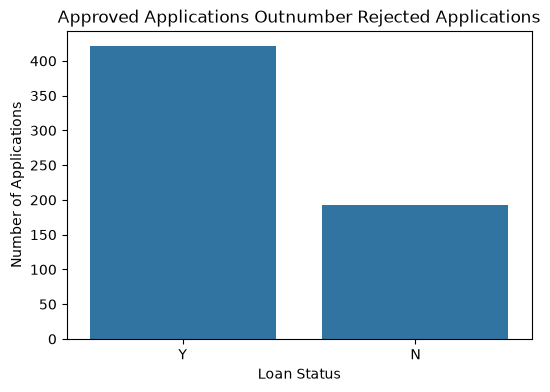

In [65]:
#Why bar chart: Loan Status is categorical, so a bar chart clearly compares the number of applications in each category.
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df_clean,
    x="Loan_Status (Approved)"
)

plt.title("Approved Applications Outnumber Rejected Applications")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")

plt.show()

- How are loan applications distributed between approval and rejection ?

##### Conclusion:
    - The chart shows the number of approved and rejected loan applications and provides the overall outcome distribution in the dataset.

#### Chart 2 — Applicant Income Distribution

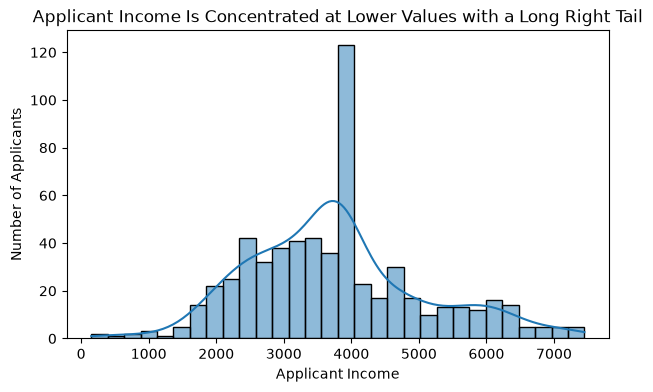

In [66]:
#Why histogram: Applicant Income is numeric, so a histogram shows its distribution and whether the values are concentrated or skewed.
plt.figure(figsize=(7, 4))

sns.histplot(
    data=df_clean,
    x="ApplicantIncome",
    bins=30,
    kde=True
)

plt.title("Applicant Income Is Concentrated at Lower Values with a Long Right Tail")
plt.xlabel("Applicant Income")
plt.ylabel("Number of Applicants")

plt.show()

- What is the distribution of Applicant Income?

##### Conclusion:
    - Applicant Income is concentrated toward lower values, with a long right tail indicating the presence of relatively high-income applicants.

#### Chart 3 — Applicant Income vs Loan Amount

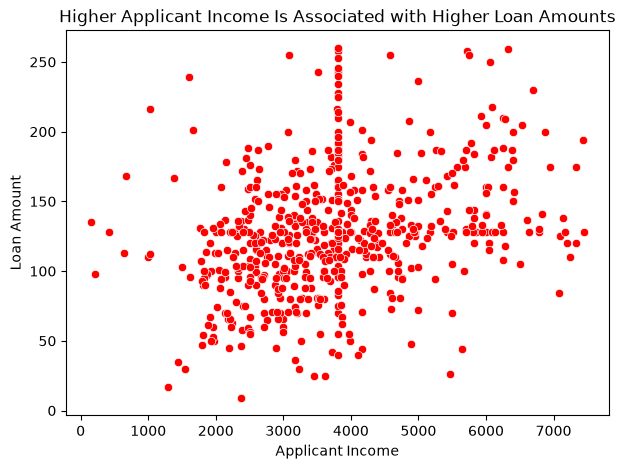

In [74]:
#Why scatter plot: Both variables are numeric, so a scatter plot shows their relationship directly.
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df_clean,
    x="ApplicantIncome",
    y="LoanAmount",
    color='red'
)

plt.title("Higher Applicant Income Is Associated with Higher Loan Amounts")
plt.xlabel("Applicant Income")
plt.ylabel("Loan Amount")

plt.show()

- Is Applicant Income related to Loan Amount?

##### Conclusion:

    - The scatter plot shows a moderate positive relationship between Applicant Income and Loan Amount, consistent with the correlation of about 0.303 found in the correlation analysis.

#### Chart 4 — Approval Rate by Credit History

In [68]:
approval_rate_credit = pd.crosstab(
    df_clean["Credit_History"],
    df_clean["Loan_Status (Approved)"],
    normalize="index"
) * 100

approval_rate_credit

Loan_Status (Approved),N,Y
Credit_History,,
0.0,68.345324,31.654676
1.0,20.421053,79.578947


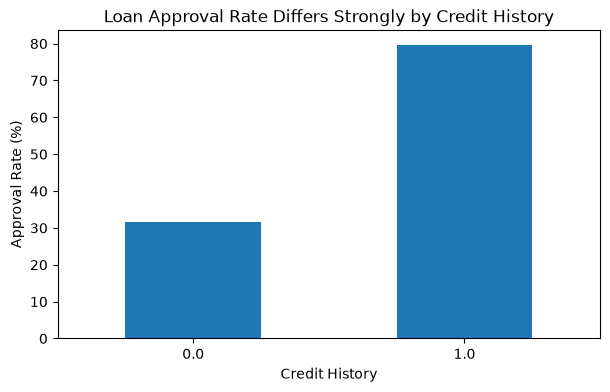

In [69]:
#Why bar chart: Credit History is categorical/binary and we are comparing approval rates between categories.
approval_rate_credit["Y"].plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Loan Approval Rate Differs Strongly by Credit History")
plt.xlabel("Credit History")
plt.ylabel("Approval Rate (%)")
plt.xticks(rotation=0)

plt.show()

- How does Credit History relate to loan approval?

##### Conclusion:

    - The approval rate differs substantially across Credit History groups, indicating that Credit History is an important variable to examine when explaining differences in loan approval outcomes.

#### Chart 5 — Applicant Income by Loan Status

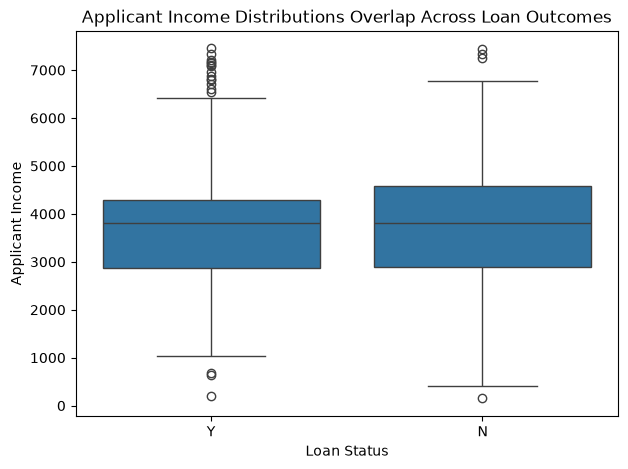

In [70]:
#Why box plot: A box plot is useful because Applicant Income contains high values/outliers, and it allows us to compare the distributions between the two groups.
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df_clean,
    x="Loan_Status (Approved)",
    y="ApplicantIncome"
)

plt.title("Applicant Income Distributions Overlap Across Loan Outcomes")
plt.xlabel("Loan Status")
plt.ylabel("Applicant Income")

plt.show()

- Does Applicant Income differ between approved and rejected applications?

##### Conclusion:

    - The two Applicant Income distributions overlap considerably, although the groups may differ in their mean values. The substantial spread and high-income observations should also be considered when interpreting the difference.

#### Chart 6 — Education + Loan Status + Applicant Income

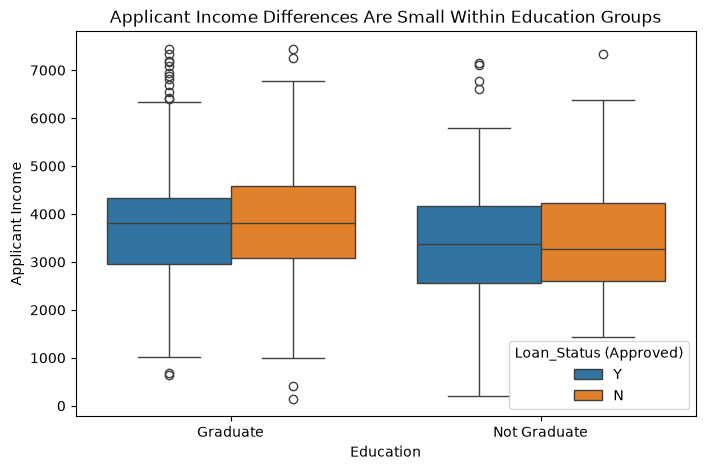

In [75]:
#Why box plot: We are comparing a numeric distribution across two categorical variables.
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Education",
    y="ApplicantIncome",
    hue="Loan_Status (Approved)"
)

plt.title("Applicant Income Differences Are Small Within Education Groups")
plt.xlabel("Education")
plt.ylabel("Applicant Income")

plt.show()

- Does Education change the relationship between Applicant Income and Loan Status?

##### Conclusion:

    - Applicant Income distributions overlap considerably within both education groups. Among graduates, the median income is the same for approved and rejected applications, while the difference among non-graduates is relatively small.

#### Chart 7 — Approval Rate by Education

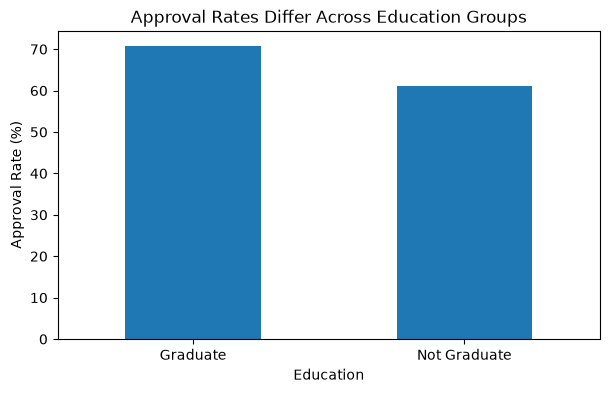

In [72]:
#Why bar chart: Education is categorical and we want to compare approval percentages between categories.
education_approval = pd.crosstab(
    df_clean["Education"],
    df_clean["Loan_Status (Approved)"],
    normalize="index"
) * 100

education_approval["Y"].plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Approval Rates Differ Across Education Groups")
plt.xlabel("Education")
plt.ylabel("Approval Rate (%)")
plt.xticks(rotation=0)

plt.show()

- Does Education relate to loan approval?

##### Conclusion:

    - The chart shows how the approval rate differs between Graduate and Not Graduate applicants. This provides a direct comparison of loan outcomes across education categories.

#### Chart 8 — Correlation Heatmap

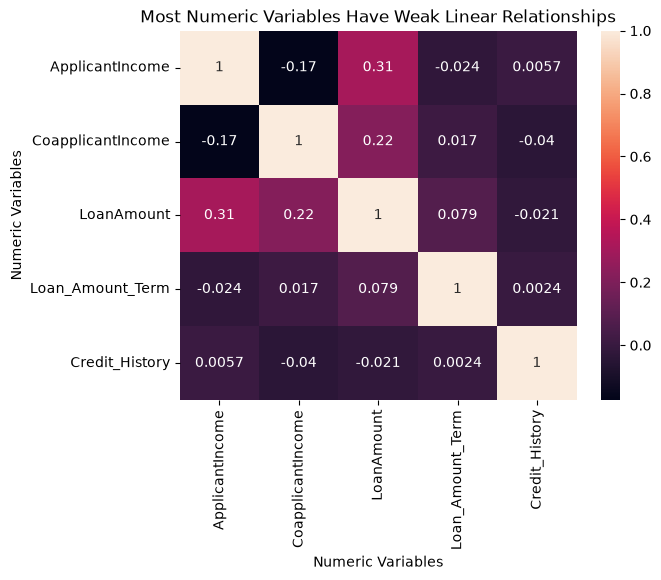

In [73]:
correlation = df_clean[
    [
        "ApplicantIncome",
        "CoapplicantIncome",
        "LoanAmount",
        "Loan_Amount_Term",
        "Credit_History"
    ]
].corr()

sns.heatmap(
    correlation,
    annot=True,
)

plt.title("Most Numeric Variables Have Weak Linear Relationships")
plt.xlabel("Numeric Variables")
plt.ylabel("Numeric Variables")

plt.show()

- How strongly are the numeric variables related to one another?

##### Conclusion:

    - Most numeric relationships are weak or near zero. ApplicantIncome and LoanAmount have the strongest positive correlation at about 0.303, followed by CoapplicantIncome and LoanAmount at about 0.249.